In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

In [4]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
Y = pd.Categorical.from_codes(data.target, data.target_names) # Convertir a variable categórica con nombres
Y

['malignant', 'malignant', 'malignant', 'malignant', 'malignant', ..., 'malignant', 'malignant', 'malignant', 'malignant', 'benign']
Length: 569
Categories (2, object): ['malignant', 'benign']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

### Clasificador Random Forest (Bagging de árboles de decisión)

In [7]:
RFC = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,max_depth=5, min_samples_leaf=4)
RFC.fit(X_train, y_train)
y_pred_rfc = RFC.predict(X_test)
print("accuracy_score Random Forest:", accuracy_score(y_test, y_pred_rfc))

accuracy_score Random Forest: 0.9707602339181286


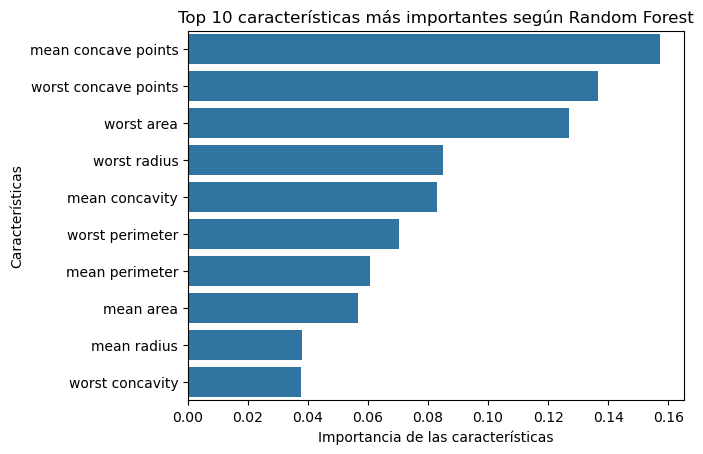

In [8]:
# Mostrar la importancia de las características
importancia_caracteristicas = pd.DataFrame(RFC.feature_importances_, index=X.columns, columns=["Importancia de las características"]).sort_values(by="Importancia de las características", ascending=False)
top_10 = importancia_caracteristicas.head(10)
sns.barplot(x=top_10["Importancia de las características"], y=top_10.index) # Crear el gráfico de barras
plt.title("Top 10 características más importantes según Random Forest")
plt.xlabel("Importancia de las características")
plt.ylabel("Características")
plt.show()

### Clasificador AdaBoost

In [11]:
ABC = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=10), n_estimators=100, random_state=42, learning_rate=0.1)
ABC.fit(X_train, y_train)
y_pred_abc = ABC.predict(X_test)
print("accuracy_score AdaBoost:", accuracy_score(y_test, y_pred_abc))

accuracy_score AdaBoost: 0.9298245614035088


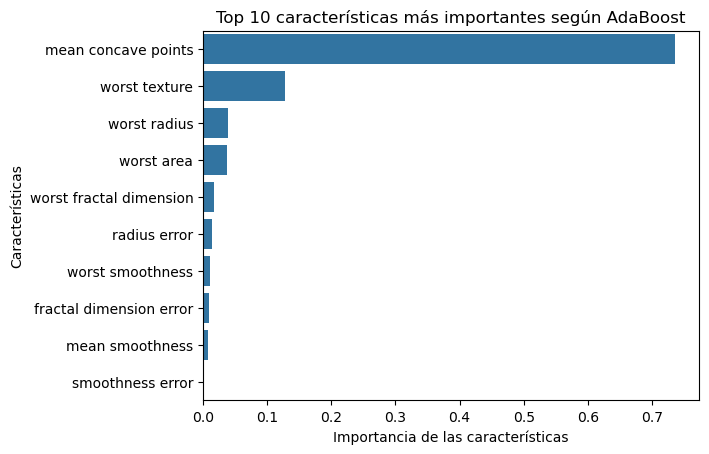

In [12]:
# Mostrar la importancia de las características
importancia_caracteristicas = pd.DataFrame(ABC.feature_importances_, index=X.columns, columns=["Importancia de las características"]).sort_values(by="Importancia de las características", ascending=False)
top_10 = importancia_caracteristicas.head(10)
sns.barplot(x=top_10["Importancia de las características"], y=top_10.index) # Crear el gráfico de barras
plt.title("Top 10 características más importantes según AdaBoost")
plt.xlabel("Importancia de las características")
plt.ylabel("Características")
plt.show()

### Clasificador Gradient Boosting

In [15]:
GBC = GradientBoostingClassifier(n_estimators=100, learning_rate=1, max_depth=10, min_samples_leaf=2, max_leaf_nodes=30, random_state=42)
GBC.fit(X_train, y_train)
y_pred_gbc = GBC.predict(X_test)
print("accuracy_score Gradient Boosting:", accuracy_score(y_test, y_pred_gbc))

accuracy_score Gradient Boosting: 0.9707602339181286


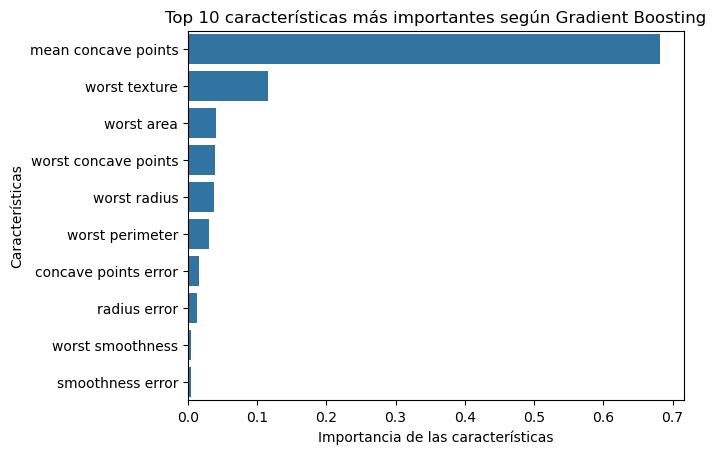

In [16]:
# Mostrar la importancia de las características
importancia_caracteristicas = pd.DataFrame(GBC.feature_importances_, index=X.columns, columns=["Importancia de las características"]).sort_values(by="Importancia de las características", ascending=False)
top_10 = importancia_caracteristicas.head(10)
sns.barplot(x=top_10["Importancia de las características"], y=top_10.index) # Crear el gráfico de barras
plt.title("Top 10 características más importantes según Gradient Boosting")
plt.xlabel("Importancia de las características")
plt.ylabel("Características")
plt.show()

### XGBoost 

In [21]:
XGBC = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=10, random_state=42, use_label_encoder=False, eval_metric='logloss')
Y_numerica = 1 - data.target  # Invertir las etiquetas (0 -> 1, 1 -> 0)
labels = list(data.target_names) # ['malignant', 'benign']
labels.reverse()  # Ahora ['benign', 'malignant']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, Y_numerica, test_size=0.3, random_state=42)

In [23]:
XGBC.fit(X_train, y_train) # Entrenar el modelo
y_pred_xgb = XGBC.predict(X_test) # Realizar predicciones
print("accuracy_score XGBoost:", accuracy_score(y_test, y_pred_xgb)) # Evaluar el modelo

c:\Users\Fran\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:16:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


accuracy_score XGBoost: 0.9590643274853801


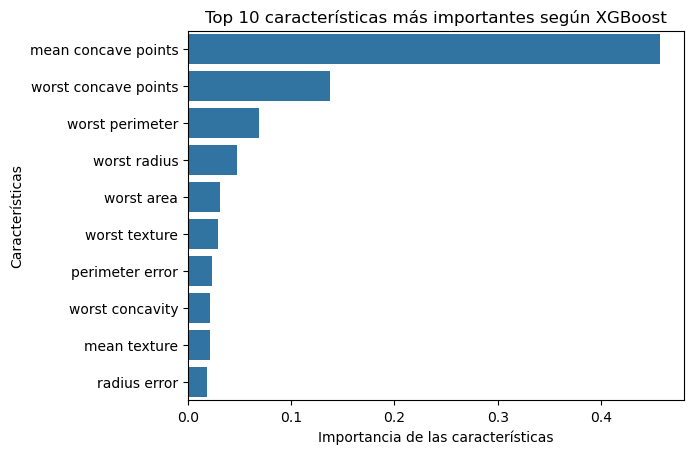

In [24]:
# Mostrar la importancia de las características
importancia_caracteristicas = pd.DataFrame(XGBC.feature_importances_, index=X.columns, columns=["Importancia de las características"]).sort_values(by="Importancia de las características", ascending=False)
top_10 = importancia_caracteristicas.head(10)
sns.barplot(x=top_10["Importancia de las características"], y=top_10.index) # Crear el gráfico de barras
plt.title("Top 10 características más importantes según XGBoost")
plt.xlabel("Importancia de las características")
plt.ylabel("Características")
plt.show()